# Classification Modeling: Hotel Booking Cancellation

This notebook predicts hotel booking cancellation using the preprocessed classification dataset, `hotel_bookings_clf.csv`. The target variable is `is_canceled`, where `0` means not canceled and `1` means canceled.

The modeling goal is not only to maximize accuracy. The main business goal is to identify high-risk cancellation bookings before the guest arrival date so that hotels can support early intervention, overbooking decisions, and resource allocation.

In [1]:
# Import libraries for classification modeling
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

FIGURE_DIR = Path('../reports/figures')
if not FIGURE_DIR.exists():
    FIGURE_DIR = Path('reports/figures')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load the Processed Classification Dataset

The preprocessing stage already handled missing values, removed invalid zero-guest bookings, created derived features, encoded categorical variables, and removed direct leakage columns. Therefore, this notebook starts from the model-ready classification CSV.

In [2]:
# Load the processed classification data
data_path = '../data/processed/hotel_bookings_clf.csv'

if not os.path.exists(data_path):
    data_path = 'data/processed/hotel_bookings_clf.csv'

df = pd.read_csv(data_path)

print('Data path:', data_path)
print('Shape:', df.shape)
display(df.head())

Data path: ../data/processed/hotel_bookings_clf.csv
Shape: (119210, 83)


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,assigned_room_type_B,assigned_room_type_C,assigned_room_type_D,assigned_room_type_E,assigned_room_type_F,assigned_room_type_G,assigned_room_type_H,assigned_room_type_I,assigned_room_type_K,assigned_room_type_L
0,0,342,2015,27,1,0,0,2,0.0,0,...,0,1,0,0,0,0,0,0,0,0
1,0,737,2015,27,1,0,0,2,0.0,0,...,0,1,0,0,0,0,0,0,0,0
2,0,7,2015,27,1,0,1,1,0.0,0,...,0,1,0,0,0,0,0,0,0,0
3,0,13,2015,27,1,0,1,1,0.0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,14,2015,27,1,0,2,2,0.0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
# Check target balance and basic data quality
print('Missing values:', int(df.isnull().sum().sum()))
print('Object columns:', len(df.select_dtypes(include='object').columns))
print('\nTarget count:')
print(df['is_canceled'].value_counts().sort_index())
print('\nTarget ratio:')
print((df['is_canceled'].value_counts(normalize=True).sort_index() * 100).round(2))

Missing values: 0
Object columns: 0

Target count:
is_canceled
0    75011
1    44199
Name: count, dtype: int64

Target ratio:
is_canceled
0    62.92
1    37.08
Name: proportion, dtype: float64


## 2. Feature and Target Setup

`is_canceled` is the target, so it must be removed from the input features. `adr` is also removed because it is the regression target in the second modeling task and was not one of the main cancellation prediction candidate features in the proposal. In addition, `assigned_room_type_*` is removed because assigned room type may not be available at the booking-time prediction stage.

The preprocessing summary mentioned that assigned room type could be tested later with feature ablation. For this baseline, the more conservative choice is to exclude it so that the model better matches the business setting of early cancellation risk prediction.

In [4]:
# Prepare X and y for cancellation prediction
target = 'is_canceled'
assigned_cols = [col for col in df.columns if col.startswith('assigned_room_type_')]
drop_cols = [target, 'adr'] + assigned_cols

X = df.drop(columns=drop_cols, errors='ignore')
y = df[target]

print('Target:', target)
print('Dropped columns:', len(drop_cols))
print('Assigned room columns removed:', len(assigned_cols))
print('Feature shape:', X.shape)
print('Target shape:', y.shape)

Target: is_canceled
Dropped columns: 12
Assigned room columns removed: 10
Feature shape: (119210, 71)
Target shape: (119210,)


## 3. Train/Test Split

The target distribution is about 63% not canceled and 37% canceled. This is not an extreme imbalance, but the class ratio is still important. Therefore, `stratify=y` is used so that the train and test sets keep almost the same target ratio as the full dataset.

In [5]:
# Split the data while keeping the target ratio stable
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('\nTrain target ratio:')
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))
print('\nTest target ratio:')
print((y_test.value_counts(normalize=True).sort_index() * 100).round(2))

Train shape: (95368, 71)
Test shape: (23842, 71)

Train target ratio:
is_canceled
0    62.92
1    37.08
Name: proportion, dtype: float64

Test target ratio:
is_canceled
0    62.92
1    37.08
Name: proportion, dtype: float64


## 4. Model Candidates

Three scikit-learn classification models are compared within the course modeling and evaluation workflow.

- Logistic Regression: a simple and interpretable linear baseline
- Decision Tree: a rule-based nonlinear classifier
- Random Forest: an ensemble model based on multiple decision trees

Logistic Regression can be affected by feature scale, so `StandardScaler` is placed inside a `Pipeline`. This is important because the scaler is fitted only on each training fold during cross validation, preventing scaling leakage.

KNN was considered but not included in the main full-data comparison because distance-based 5-fold cross validation on 119,210 rows is computationally expensive. The current set still covers a simple interpretable baseline, a tree model, and an ensemble model.

In [6]:
# Build simple classification models for comparison
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(
        n_estimators=50,
        max_depth=12,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['accuracy', 'precision', 'recall', 'f1']

print('Models:', list(models.keys()))
print('CV:', cv)

Models: ['Logistic Regression', 'Decision Tree', 'Random Forest']
CV: StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


Running: Logistic Regression


Running: Decision Tree


Running: Random Forest


,model,cv_accuracy,cv_precision,cv_recall,cv_f1
1,Decision Tree,0.8401,0.8142,0.7371,0.7737
2,Random Forest,0.8477,0.8645,0.6989,0.7729
0,Logistic Regression,0.8075,0.8029,0.6373,0.7105


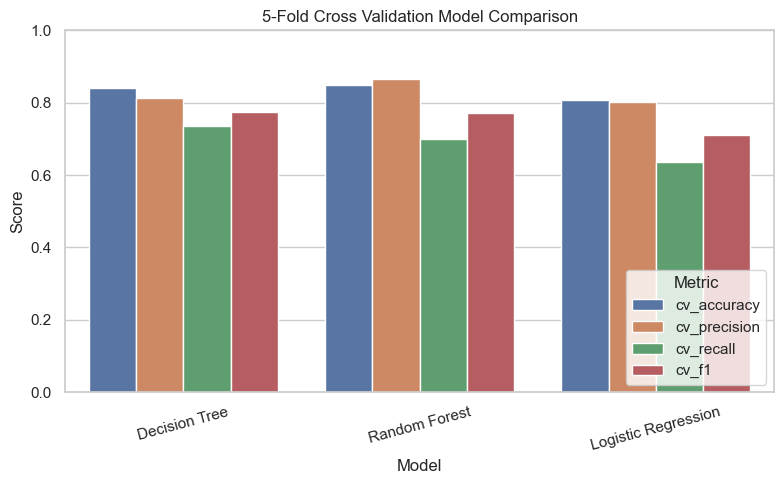

Saved figure: ..\reports\figures\classification_model_comparison.png


In [7]:
# Compare models with 5-fold cross validation on the training data
cv_rows = []

for name, model in models.items():
    print('Running:', name)
    score = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )
    cv_rows.append({
        'model': name,
        'cv_accuracy': score['test_accuracy'].mean(),
        'cv_precision': score['test_precision'].mean(),
        'cv_recall': score['test_recall'].mean(),
        'cv_f1': score['test_f1'].mean()
    })

cv_result = pd.DataFrame(cv_rows).sort_values('cv_f1', ascending=False)
display(cv_result.round(4))

fig, ax = plt.subplots(figsize=(8, 5))
plot_df = cv_result.melt(id_vars='model', value_vars=['cv_accuracy', 'cv_precision', 'cv_recall', 'cv_f1'])
sns.barplot(data=plot_df, x='model', y='value', hue='variable', ax=ax)
ax.set_ylim(0, 1)
ax.set_title('5-Fold Cross Validation Model Comparison')
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.legend(title='Metric', loc='lower right')
plt.xticks(rotation=15)
plt.tight_layout()
comparison_path = FIGURE_DIR / 'classification_model_comparison.png'
plt.savefig(comparison_path, dpi=300, bbox_inches='tight')
plt.show()
print('Saved figure:', comparison_path)

## 5. Final Test Evaluation

The final model is selected using cross-validation F1-score, not accuracy alone. In cancellation prediction, recall is important because missed cancellations can cause business loss, while precision is also important because too many false alarms can create unnecessary operational work.

The Decision Tree and Random Forest results are very close. Decision Tree is selected not because it is overwhelmingly better, but because it has the slightly higher F1-score, higher recall, and better interpretability for presentation.

In [8]:
# Train the best model and evaluate it on the test data
best_name = cv_result.iloc[0]['model']
best_model = models[best_name]
safe_name = best_name.lower().replace(' ', '_')

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

test_result = pd.DataFrame([{
    'model': best_name,
    'test_accuracy': accuracy_score(y_test, y_pred),
    'test_precision': precision_score(y_test, y_pred),
    'test_recall': recall_score(y_test, y_pred),
    'test_f1': f1_score(y_test, y_pred)
}])

print('Best model:', best_name)
display(test_result.round(4))
print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=['Not canceled', 'Canceled']))

Best model: Decision Tree


,model,test_accuracy,test_precision,test_recall,test_f1
0,Decision Tree,0.8399,0.8095,0.7431,0.7749



Classification report:
              precision    recall  f1-score   support

Not canceled       0.86      0.90      0.88     15002
    Canceled       0.81      0.74      0.77      8840

    accuracy                           0.84     23842
   macro avg       0.83      0.82      0.83     23842
weighted avg       0.84      0.84      0.84     23842



,Predicted not canceled,Predicted canceled
Actual not canceled,13456,1546
Actual canceled,2271,6569


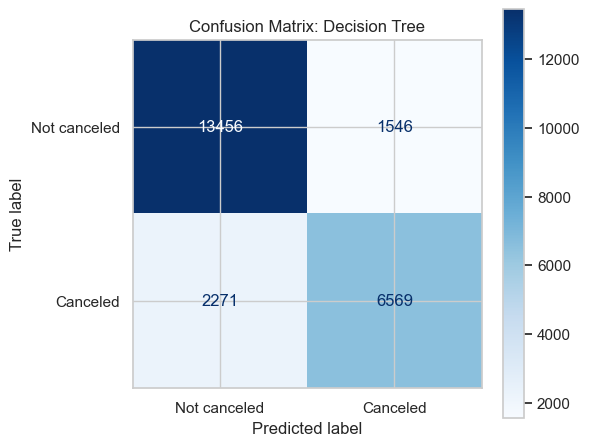

Saved figure: ..\reports\figures\confusion_matrix_decision_tree.png


In [9]:
# Display the confusion matrix for the selected model
cm = confusion_matrix(y_test, y_pred)
cm_table = pd.DataFrame(
    cm,
    index=['Actual not canceled', 'Actual canceled'],
    columns=['Predicted not canceled', 'Predicted canceled']
)

display(cm_table)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not canceled', 'Canceled'])
disp.plot(cmap='Blues', values_format='d', ax=ax)
ax.set_title(f'Confusion Matrix: {best_name}')
plt.tight_layout()
confusion_path = FIGURE_DIR / f'confusion_matrix_{safe_name}.png'
plt.savefig(confusion_path, dpi=300, bbox_inches='tight')
plt.show()
print('Saved figure:', confusion_path)

## 6. Feature Interpretation

If the selected model is tree-based, feature importance is used for interpretation. If the selected model is Logistic Regression, absolute coefficient size is used instead. These values help explain which booking characteristics the model used most strongly.

Feature importance should not be interpreted as causality. It only shows how much the trained model used each feature for prediction.

,feature,importance
37,deposit_type_Non Refund,0.4300
31,market_segment_Online TA,0.1117
15,total_of_special_requests,0.0896
62,country_PRT,0.0759
0,lead_time,0.0750
14,required_car_parking_spaces,0.0413
10,previous_cancellations,0.0384
1,arrival_date_year,0.0351
12,booking_changes,0.0188
40,customer_type_Transient,0.0133


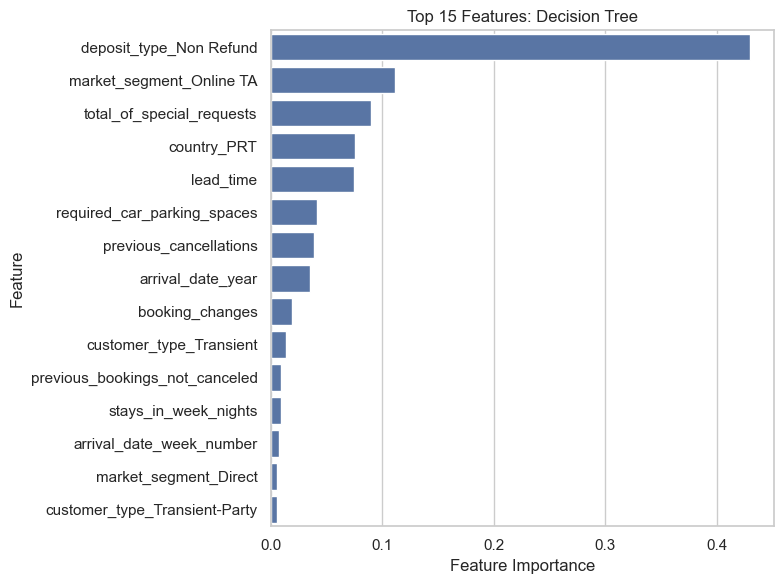

Saved figure: ..\reports\figures\classification_feature_importance.png


In [10]:
# Show important features from the selected model
model_part = best_model.named_steps['model'] if hasattr(best_model, 'named_steps') else best_model

if hasattr(model_part, 'feature_importances_'):
    importance = model_part.feature_importances_
    title = 'Feature Importance'
elif hasattr(model_part, 'coef_'):
    importance = np.abs(model_part.coef_[0])
    title = 'Absolute Coefficient'
else:
    importance = np.zeros(len(X.columns))
    title = 'Importance'

imp_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importance
}).sort_values('importance', ascending=False).head(15)

display(imp_df.round(4))

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=imp_df, x='importance', y='feature', ax=ax, color='#4C72B0')
ax.set_title(f'Top 15 Features: {best_name}')
ax.set_xlabel(title)
ax.set_ylabel('Feature')
plt.tight_layout()
importance_path = FIGURE_DIR / 'classification_feature_importance.png'
plt.savefig(importance_path, dpi=300, bbox_inches='tight')
plt.show()
print('Saved figure:', importance_path)

In [11]:
# Summarize the final classification result
print('Final selected model:', best_name)
print('Number of input features:', X.shape[1])
print('Excluded adr:', 'adr' in drop_cols)
print('Excluded assigned_room_type columns:', len(assigned_cols))
print('\nTest scores:')
print(test_result.round(4).to_string(index=False))
print('\nConfusion matrix:')
print(cm_table.to_string())

Final selected model: Decision Tree
Number of input features: 71
Excluded adr: True
Excluded assigned_room_type columns: 10

Test scores:
        model  test_accuracy  test_precision  test_recall  test_f1
Decision Tree         0.8399          0.8095       0.7431   0.7749

Confusion matrix:
                     Predicted not canceled  Predicted canceled
Actual not canceled                   13456                1546
Actual canceled                        2271                6569


## Modeling Conclusion

This notebook compares classification models for hotel booking cancellation prediction using the preprocessed classification dataset. The final model is selected based on 5-fold cross-validation F1-score and then evaluated again on the hold-out test set with accuracy, precision, recall, F1-score, and a confusion matrix.

The final Decision Tree model is a defensible baseline because its test F1-score is close to the cross-validation F1-score, its recall is stronger than Random Forest, and its tree-based logic is easier to explain in a project presentation.